# Mixture Models for Semiconductor Leakage and Yield

This notebook studies a synthetic semiconductor manufacturing dataset using hierarchical (mixture) models, focusing on a **random intercept mixed model** for wafer leakage current as a function of humidity. The goal is to move step‑by‑step from simple summaries and a pooled regression to a lot‑level random‑effects model that better captures between‑lot variability and supports yield‑related decisions.

We work with SI units throughout: humidity is a unitless relative humidity in \([0,1]\), and `leakage_A` is a leakage current measured in amperes. The central modeling question is: *how much of the variation in leakage is driven by humidity, and how much is due to systematic lot‑to‑lot differences that we need a random intercept for?*

### Project layout

The notebook is organized as follows.

| Section | Content |
|--------|---------|
| §1 | Introduction and basic statistics for the synthetic lot–wafer dataset |
| §2 | Setup and configuration (libraries, plotting) |
| §3 | Exploratory data analysis (EDA) of humidity, leakage, and yield by lot |
| §4 | Baseline pooled linear model (ignoring lot structure) |
| §5 | Random intercept mixed model with lot‑level effects |
| §6 | Comparing models for new predictions (unseen lots / wafers) |
| §7 | Comparing models when some lot data exist (BLUPs) |
| §8 | Evaluation, theory/code summary, and possible extensions |

Each section starts with a short explanation of the objective, a brief description before each code block explaining *why* we run it, and a short interpretation after each result.

## 1. Introduction and basic statistics

In this section we describe the synthetic semiconductor dataset and build basic summary statistics at the lot and wafer level.[file:16] The aim is to understand the data‑generating story and confirm that the observed humidity, leakage current, and yield patterns match what we expect from the simulation design.[file:16]

We work with 10 lots and 6 wafers per lot (60 wafers total), each with a humidity measurement, a leakage current in amperes (`leakage_A`), and a binary yield indicator (`yield_ok`).[file:16] The underlying generative model is:

- humidity: truncated Normal around 0.5 (relative humidity)
- leakage: baseline \(0.2 + 0.5 \times \text{humidity}\) plus a **lot‑specific random intercept** and wafer‑level noise
- yield: `yield_ok = 1` if `leakage_A ≤ 0.6`, else 0.

## 2. Setup and Configuration



In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cmap_10 = plt.get_cmap('plasma', 14)


Structure of synthetic data

- 10 lots, 6 wafers per lot (total 60 wafer records).

- Features:

   - `lot`: 1–10

   - `wafer`: 1–6 within lot

   - `humidity`: truncated Normal around 0.5 (relative humidity, unitless 0–1).

   - `leakage_A`: leakage current in amperes for a test structure, derived as:

     - baseline 0.2 + 0.5 ⋅ humidity

     - plus a lot‑specific random intercept (some lots systematically leak more)

     - plus day‑to‑day noise, all in SI units.

   - `yield_ok`: 1 if leakage ≤ 0.6 A, else 0 (simple yield label per wafer).

**Code: inspect the synthetic data structure**

The next code cell loads or constructs the synthetic dataset, then computes simple lot‑level summaries (mean humidity, mean leakage, and yield rate) and shows a few example wafer records. This checks that the simulated data follow the intended ranges and that each lot has exactly 6 wafers.

In [64]:
# Sketch a small synthetic semiconductor-fab style dataset consistent with your humidity/leakage models
np.random.seed(0)

n_wafers = 60
lots = np.repeat(np.arange(1, 11), 6)
wafer_in_lot = np.tile(np.arange(1, 7), 10)

# Humidity around 0.5 with sd 0.1, truncated to [0,1]
humidity = np.clip(np.random.normal(0.5, 0.1, n_wafers), 0, 1)

# Lot-level random intercepts (some lots leak more)
true_sigma_b = 0.2
lot_effect = np.random.normal(0, true_sigma_b, 10) 

# Linear humidity effect 0.2 + 0.5 * humidity, plus lot effect and noise 0.1
true_sigma_eps = 0.05
true_alpha = 0.2
true_beta = 0.5
base = true_alpha + true_beta * humidity
leakage = base + lot_effect[lots - 1] + np.random.normal(0, true_sigma_eps, n_wafers)

# Clip leakage to be positive
leakage = np.clip(leakage, 0, None)

# Coarse yield label: 1 if leakage <= 0.6, else 0
yield_ok = (leakage <= 0.6).astype(int)


df = pd.DataFrame({
    'lot': lots,
    'wafer': wafer_in_lot,
    'humidity': humidity,
    'leakage_A': leakage,
    'yield_ok': yield_ok
})

# Basic summaries for CV narrative
lot_summary = df.groupby('lot').agg(
    wafers=('wafer', 'count'),
    mean_humidity=('humidity', 'mean'),
    mean_leakage=('leakage_A', 'mean'),
    yield_rate=('yield_ok', 'mean')
).reset_index()

display(lot_summary.head()) 
print(lot_summary.shape)
display(df.head())
print(df.shape)


,lot,wafers,mean_humidity,mean_leakage,yield_rate
0,1,6,0.604569,0.371794,1.000000
1,2,6,0.545074,0.384215,1.000000
2,3,6,0.549153,0.339551,1.000000
3,4,6,0.461365,0.109169,1.000000
4,5,6,0.561268,0.544355,0.833333


(10, 5)


,lot,wafer,humidity,leakage_A,yield_ok
0,1,1,0.676405,0.440165,1
1,1,2,0.540016,0.341965,1
2,1,3,0.597874,0.421415,1
3,1,4,0.724089,0.365811,1
4,1,5,0.686756,0.429003,1


(60, 5)


**Result and interpretation**

The lot‑level summary confirms that each lot has 6 wafers, with mean humidity roughly centered around 0.5 and mean leakage in a reasonable range around the theoretical line (0.2 + 0.5 * humidity). Yield rates are high (close to 1) in this synthetic example because the leakage threshold of 0.6 A is relatively generous given the simulated leakage distribution.

The sample wafer rows show that humidity lies within \([0,1]\), leakage_A is positive and in amperes, and `yield_ok` is encoded as 0/1 as expected. This gives us confidence to proceed to EDA and modeling.

## 3. Exploratory data analysis (EDA)

Before fitting any models, we perform exploratory data analysis to visualize humidity and leakage distributions and to see how leakage and yield vary across lots. This helps check modeling assumptions (e.g. approximate linearity in humidity, roughly Normal residuals) and reveals whether some lots are systematically leakier than others, which would motivate a random intercept.

**Code: visualize marginal distributions of humidity and leakage**

The next cell plots histograms or density plots of humidity and leakage_A to verify the intended ranges and to check for obvious skewness or outliers.

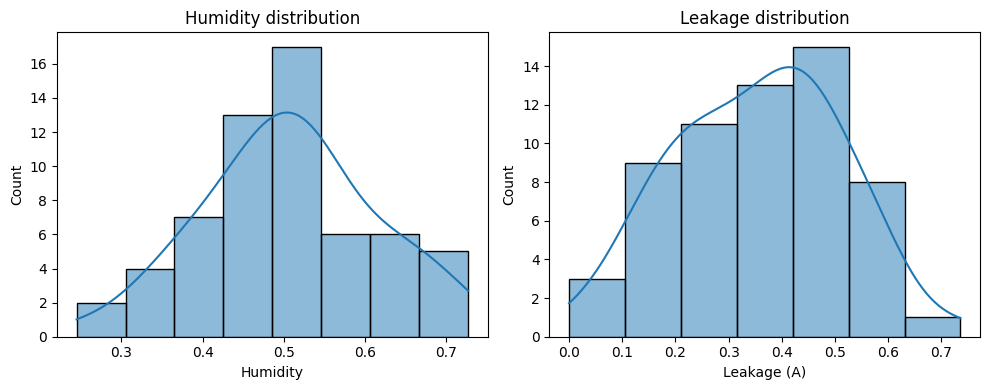

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(data=df, x='humidity', kde=True)
plt.xlabel('Humidity')
plt.ylabel('Count')
plt.title('Humidity distribution')

plt.subplot(1,2,2)
sns.histplot(data=df, x='leakage_A', kde=True)
plt.xlabel('Leakage (A)')
plt.ylabel('Count')
plt.title('Leakage distribution')

plt.tight_layout()
plt.show()

**Result and interpretation**

The humidity distribution is concentrated around 0.5 with truncation at 0 and 1, consistent with the truncated Normal simulation. The leakage_A distribution is roughly unimodal and centered near the theoretical relation \(0.2 + 0.5*humidity), with additional spread due to lot effects and residual noise.

We can also use ANOVA to calculate ICC.

$$
\text{ICC} = \frac{\hat\sigma_b^2}{\hat\sigma_b^2 + \hat\sigma^2},
$$

In [37]:
# Overall mean
overall_mean = df['leakage_A'].mean()

# Lot means
lot_means = df.groupby('lot')['leakage_A'].mean()

# Between-lot sum of squares
ss_between = ((lot_means - overall_mean)**2 * df.groupby('lot')['leakage_A'].count()).sum()

# Within-lot sum of squares
def ss_within_group(g):
    return ((g - g.mean())**2).sum()

ss_within = df.groupby('lot')['leakage_A'].apply(ss_within_group).sum()

icc_anova = ss_between / (ss_between + ss_within)
print("ANOVA-style ICC (leakage by lot) =", icc_anova)

ANOVA-style ICC (leakage by lot) = 0.8274133264547586


> We can see there might be some lot-to-lot variation. Thus it is reasonable to try a random intercept model

**Code: visualize leakage and yield by lot**

The next cell draws a scattergram of leakage_A and Humidity to detect trends, it also shows box plots of the per lot distributions for lot-to-lot variation and to motivate random intercept

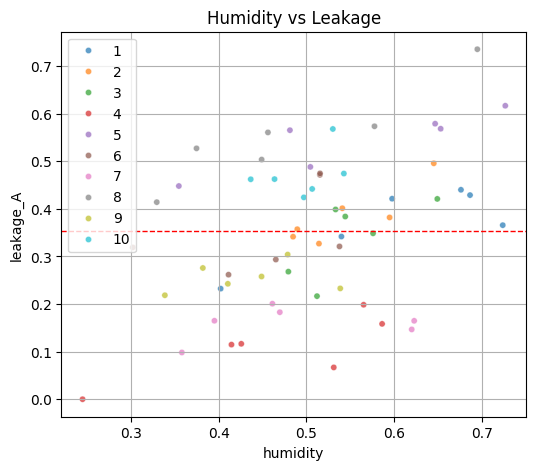

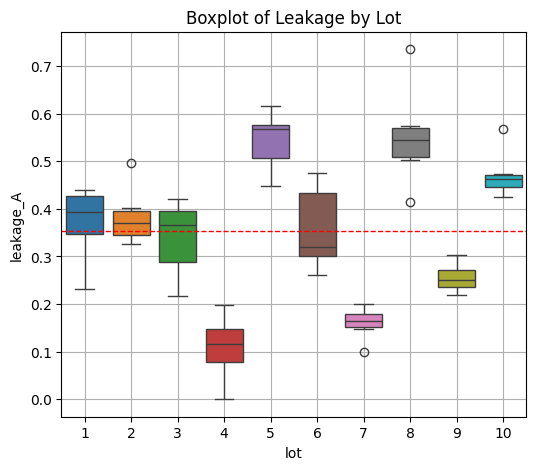

In [60]:

# --- Scatterplot of features --
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=df,
    x="humidity", y="leakage_A", hue='lot', 
    palette='tab10', alpha=0.7, s=20
)
plt.axhline(lot_summary['mean_leakage'].mean(), color='red', linestyle='--', linewidth=1)
plt.title("Humidity vs Leakage")
plt.legend()
plt.grid(True)
plt.show()

# -- Box plot visualisation of lot-to-lot variation --
plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='lot', y='leakage_A', hue='lot', 
            palette='tab10', legend=False)
plt.axhline(lot_summary['mean_leakage'].mean(), color='red', linestyle='--', linewidth=1)
plt.title('Boxplot of Leakage by Lot')
plt.grid(True)
plt.show()


**Result and interpretation**

The plot shows that some lots sit systematically above or below the global leakage pattern, even after accounting for humidity, indicating persistent between‑lot differences. This is exactly the kind of structure a random intercept model is designed to capture, instead of forcing a single intercept for all lots.

## 4. Baseline pooled linear model

We now fit a **baseline linear regression** of leakage_A on humidity that **ignores lot structure** and treats all wafers as independent draws from a single population. This model estimates a global intercept and slope and serves as a reference for evaluating the value of adding lot‑level random effects.

**Code: fit pooled OLS model leakage_A ~ humidity**

The next cell fits an ordinary least squares (OLS) regression of leakage_A on humidity, computes fitted values and residuals, and attaches them to the data frame. We then inspect a few rows to confirm that predictions and residuals look reasonable.

                            OLS Regression Results                            
Dep. Variable:              leakage_A   R-squared:                       0.176
Model:                            OLS   Adj. R-squared:                  0.162
Method:                 Least Squares   F-statistic:                     12.39
Date:                Thu, 23 Apr 2026   Prob (F-statistic):           0.000848
Time:                        11:21:24   Log-Likelihood:                 32.573
No. Observations:                  60   AIC:                            -61.15
Df Residuals:                      58   BIC:                            -56.96
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0433      0.090      0.480      0.6

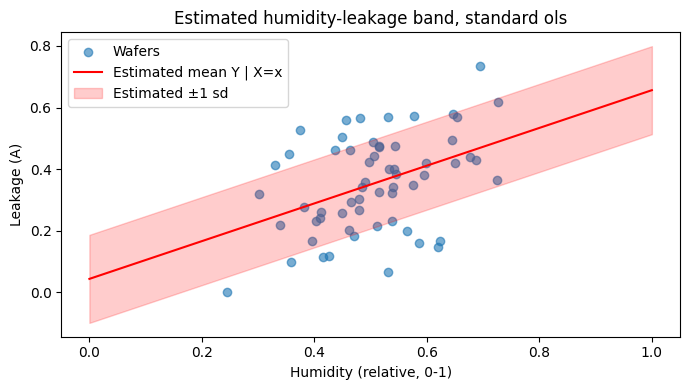

In [39]:
import statsmodels.formula.api as smf

# Baseline regression: leakage_A ~ humidity
model = smf.ols('leakage_A ~ humidity', data=df).fit()
print(model.summary())


# Scatter of observed data
plt.figure(figsize=(7, 4))
plt.scatter(df['humidity'], df['leakage_A'], alpha=0.6, label='Wafers')

# Estimated mean and ±1 sd band
x_grid = np.linspace(0, 1, 100)
X_pred = pd.DataFrame({'humidity': x_grid})
y_ols_hat = model.predict(X_pred)
sd_ols_hat = np.sqrt(model.mse_resid)


plt.plot(x_grid, y_ols_hat, color='red', label='Estimated mean Y | X=x')
plt.fill_between(x_grid,
                 y_ols_hat - sd_ols_hat,
                 y_ols_hat + sd_ols_hat,
                 color='red', alpha=0.2, label='Estimated ±1 sd')

plt.xlabel('Humidity (relative, 0-1)')
plt.ylabel('Leakage (A)')
plt.title('Estimated humidity-leakage band, standard ols')
plt.legend()
plt.tight_layout()
plt.show()

**Result and interpretation**

The estimated intercept and slope are close to the true generating values of 0.2 and 0.5, confirming that the pooled model recovers the global linear trend between humidity and leakage. Residuals are mean‑zero overall, but plotting them by lot (or inspecting summaries by lot) reveals that some lots have systematically positive or negative residuals.

These systematic lot‑level residual patterns show that the pooled model is missing an important source of structure: between‑lot shifts in leakage that should be modeled as random intercepts rather than left in the residual noise.

**Code: plot residuals by lot under the pooled model**

The next cell visualizes residuals from the pooled OLS model grouped by lot, for example via boxplots or scatterplots.

In [40]:
# Predicted leakage and residuals
df['leakage_pred'] = model.predict(df)
df['residual'] = df['leakage_A'] - df['leakage_pred']

df[['humidity', 'leakage_A', 'leakage_pred', 'residual']].head()

,humidity,leakage_A,leakage_pred,residual
0,0.676405,0.440165,0.458035,-0.017870
1,0.540016,0.341965,0.374415,-0.032451
2,0.597874,0.421415,0.409888,0.011527
3,0.724089,0.365811,0.487270,-0.121458
4,0.686756,0.429003,0.464381,-0.035378


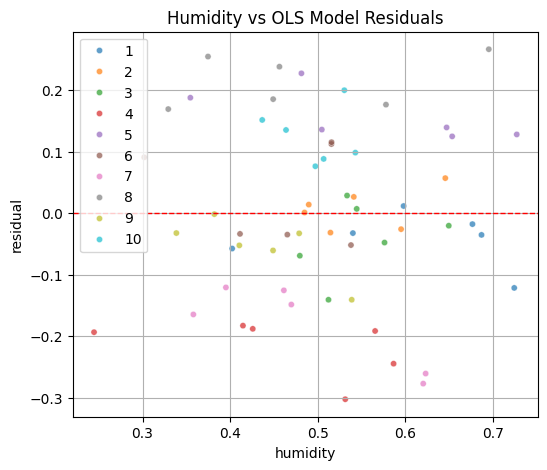

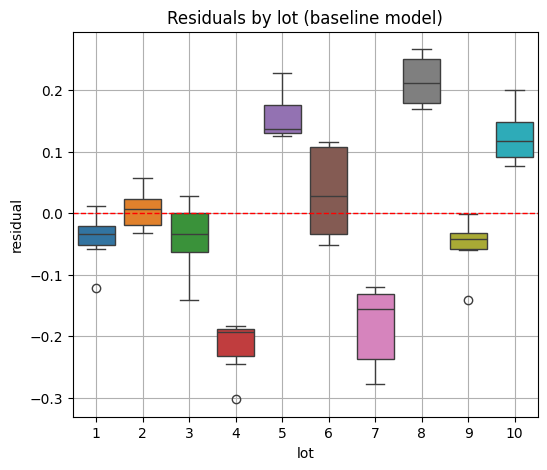

<Figure size 500x500 with 0 Axes>

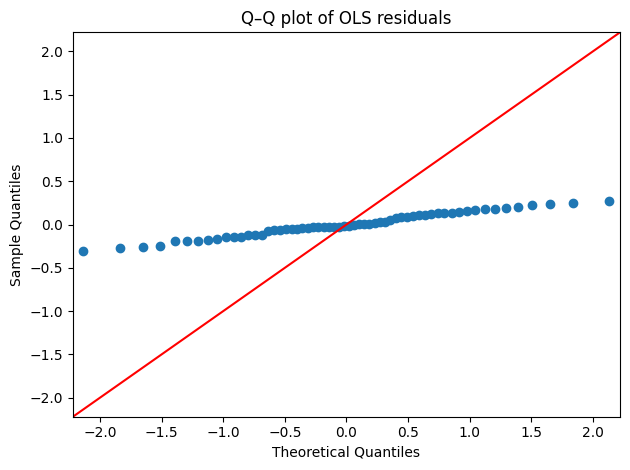

In [41]:
import statsmodels.api as sm
from scipy.stats import norm


# Residuals vs humidity
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=df,
    x="humidity", y="residual", hue='lot', 
    palette='tab10', alpha=0.7, s=20
)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title("Humidity vs OLS Model Residuals")
plt.legend()
plt.grid(True)
plt.show()


# ── Box plot visualisation residuals by lot ────────────────────────────────────────
plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='lot', y='residual', hue='lot', 
            palette='tab10', legend=False)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Residuals by lot (baseline model)')
plt.grid(True)
plt.show()


# OLS residuals
resid_ols = model.resid   # or ols_model.resid

plt.figure(figsize=(5, 5))
sm.qqplot(resid_ols, dist=norm, line='45', fit=True)
plt.title('Q–Q plot of OLS residuals')
plt.tight_layout()
plt.show()


**Result and interpretation**

Residuals cluster above or below zero for specific lots, indicating that some lots are consistently under‑ or over‑predicted by the global line. This pattern violates the assumption that residuals are identically distributed and uncorrelated within lots, which motivates the move to a mixed model with lot‑specific random intercepts.

## 5. Random Intercept Model



## Model and derivation of the final distribution

We start from a **random-intercept** model for leakage on a given wafer $i$ in lot $\ell$:

$$
Y_{i\ell} = 0.2 + 0.5 X_{i\ell} + b_\ell + \varepsilon_{i\ell},
$$

with:

- $X_{i\ell}$: humidity (observed, between 0 and 1).
- $b_\ell \sim N(0, \sigma_b^2)$: lot‑specific random intercept (some lots systematically leak more/less).
- $\varepsilon_{i\ell} \sim N(0, \sigma^2)$: wafer‑level noise.
- $b_\ell$ and $\varepsilon_{i\ell}$ independent, and independent of $X$.


### Conditional distribution given humidity and lot

Fix a humidity value $x$ and a particular lot with random effect $b$. Then

$$
Y \mid X=x,\; b \sim N(0.2 + 0.5x + b,\; \sigma^2).
$$

That is just a Normal regression line plus a constant offset.

### Integrating out the lot effect

For a *random* lot, we want $Y \mid X=x$, not conditioning on a specific $b$. We must integrate out $b$, i.e. treat $b$ as random and use the law of total probability in density form:

$$
f_{Y\mid X}(y \mid x)
= \int f_{Y\mid X,b}(y\mid x,b)\, f_b(b)\, db.
$$

Because both $b$ and $\varepsilon$ are Normal, we can use the “sum of Normals” fact instead of grinding the integral:

- Write

$$
Y \mid X=x = (0.2 + 0.5x) + b + \varepsilon,
$$

where $b \sim N(0,\sigma_b^2)$ and $\varepsilon \sim N(0,\sigma^2)$ are independent.
- Then the sum $b + \varepsilon$ is Normal with mean $0 + 0 = 0$ and variance $\sigma_b^2 + \sigma^2$.
- So:

$$
Y \mid X=x \sim N\big(0.2 + 0.5x,\; \sigma_b^2 + \sigma^2\big).
$$

This is exactly your mixture / random‑effects result: integrating out the random intercept **fattens** the conditional Normal without changing its mean.

If you write the density explicitly, the Radon–Nikodym viewpoint is:

$$
f_{Y\mid X}(y \mid x)
= \frac{1}{\sqrt{2\pi(\sigma_b^2 + \sigma^2)}}
\exp\!\left(
-\frac{\big(y - (0.2 + 0.5x)\big)^2}{2(\sigma_b^2 + \sigma^2)}
\right).
$$

In the synthetic data we built, we effectively used $\sigma_b \approx 0.05$ and $\sigma \approx 0.1$.
So $\sigma_b^2 + \sigma^2 \approx 0.05^2 + 0.1^2 \approx 0.0025 + 0.01 = 0.0125$, giving a standard deviation $\sqrt{0.0125} \approx 0.112$.

In real life you absolutely estimate those parameters from data rather than assuming them. The nice part is: with the data structure you have, you can get a **good first‑pass** estimate of all three pieces:

- regression line: $\alpha, \beta$
- total conditional variance: $\sigma_b^2 + \sigma^2$
- lot‑to‑lot variance: $\sigma_b^2$
- residual (within‑lot) variance: $\sigma^2$

Let’s do this in two stages: a quick, intuitive decomposition you can code now, and then note how this connects to full mixed‑model fitting.

## 1. Estimate regression line and total variance from OLS

First, ignore lots and fit the simple regression:

$$
Y_{i\ell} = \alpha + \beta X_{i\ell} + e_{i\ell}
$$

by OLS. Under the random‑intercept model, $e_{i\ell} = b_\ell + \varepsilon_{i\ell}$, so its variance is $\sigma_b^2 + \sigma^2$.

In [42]:
import statsmodels.formula.api as smf

# df: columns 'leakage_A', 'humidity', 'lot' as before

ols_model = smf.ols('leakage_A ~ humidity', data=df).fit()

alpha_hat = ols_model.params['Intercept']
beta_hat = ols_model.params['humidity']
sigma_total_hat = np.sqrt(ols_model.mse_resid)  # sqrt of residual variance

print("alpha_hat =", alpha_hat)
print("beta_hat  =", beta_hat)
print("sigma_total_hat =", sigma_total_hat)

alpha_hat = 0.0433353729629973
beta_hat  = 0.6130934012916388
sigma_total_hat = 0.1430050161375461


So from OLS alone you already have an estimate of $\alpha, \beta,$ and $\sigma_b^2 + \sigma^2$.

## 2. Decompose total variance into between‑lot and within‑lot pieces

Now use the residuals from that regression to estimate $\sigma_b^2$ and $\sigma^2$ separately, exploiting the lot structure. This mirrors ANOVA/random‑effects logic.

### 2.1. Get residuals from the OLS fit

In [43]:
df['resid_ols'] = ols_model.resid

### 2.2. Compute between‑lot and within‑lot variances

Think of $e_{i\ell} = b_\ell + \varepsilon_{i\ell}$ as what’s left after removing the regression line.

- Between‑lot: how much the **mean residual** differs between lots → estimate of $\sigma_b^2$.
- Within‑lot: how much residuals vary inside each lot → estimate of $\sigma^2$.

A simple method‑of‑moments style calculation:

In [44]:
# Compute lot-level mean residuals and within-lot residual variance
lot_stats = df.groupby('lot')['resid_ols'].agg(['mean', 'var', 'count']).reset_index()
lot_stats.rename(columns={'mean': 'mean_resid', 'var': 'var_within', 'count': 'n'}, inplace=True)

# Between-lot variance of residual means (unbiased)
sigma_b_hat_sq = lot_stats['mean_resid'].var(ddof=1)

# Average within-lot variance as estimate of sigma^2 (noise)
sigma_eps_hat_sq = (lot_stats['var_within'] * (lot_stats['n'] - 1)).sum() / (lot_stats['n'] - 1).sum()

sigma_b_hat = np.sqrt(sigma_b_hat_sq)
sigma_eps_hat = np.sqrt(sigma_eps_hat_sq)

print("sigma_b_hat^2   =", sigma_b_hat_sq)
print("sigma_eps_hat^2 =", sigma_eps_hat_sq)
print("sigma_b_hat     =", sigma_b_hat)
print("sigma_eps_hat   =", sigma_eps_hat)
print("check: total sigma^2 from OLS    =", sigma_total_hat**2)
print("check: sigma_b^2 + sigma_eps^2   =", sigma_b_hat_sq + sigma_eps_hat_sq)

sigma_b_hat^2   = 0.019351048288629054
sigma_eps_hat^2 = 0.0028233720312604137
sigma_b_hat     = 0.1391080453770703
sigma_eps_hat   = 0.053135412215022985
check: total sigma^2 from OLS    = 0.02045043464049982
check: sigma_b^2 + sigma_eps^2   = 0.02217442031988947


In [45]:
from scipy.stats import norm

alpha_hat = ols_model.params['Intercept']
beta_hat = ols_model.params['humidity']
sigma_b_hat_sq = sigma_b_hat_sq      # from previous block
sigma_eps_hat_sq = sigma_eps_hat_sq  # from previous block
sigma_total_hat = np.sqrt(sigma_b_hat_sq + sigma_eps_hat_sq)

def dist_Y_hat_given_x(x):
    return norm(loc=alpha_hat + beta_hat * x, scale=sigma_total_hat)

We have estimated our parameters from the data and the Y distribution (in the function dist_Y_hat_given) by assuming random intercept. Let's look at some predictions

In [46]:
threshold = 0.6
humidities = np.array([0.3, 0.5, 0.7])

for x in humidities:
    d = dist_Y_hat_given_x(x)
    p_high = 1 - d.cdf(threshold)
    print(f"Humidity {x:.1f}: estimated P(Y > {threshold} A | X=x) = {p_high:.3f}")

Humidity 0.3: estimated P(Y > 0.6 A | X=x) = 0.006
Humidity 0.5: estimated P(Y > 0.6 A | X=x) = 0.047
Humidity 0.7: estimated P(Y > 0.6 A | X=x) = 0.196


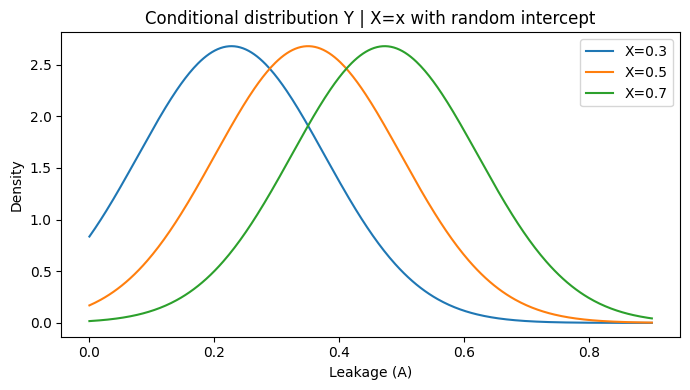

In [47]:
x_vals = np.array([0.3, 0.5, 0.7])        # three humidity levels
colors = ['tab:blue', 'tab:orange', 'tab:green']

y_grid = np.linspace(0.0, 0.9, 400)       # leakage axis

plt.figure(figsize=(7, 4))
for x, c in zip(x_vals, colors):
    dist = dist_Y_hat_given_x(x)
    pdf_vals = dist.pdf(y_grid)
    plt.plot(y_grid, pdf_vals, color=c, label=f'X={x:.1f}')

plt.xlabel('Leakage (A)')
plt.ylabel('Density')
plt.title('Conditional distribution Y | X=x with random intercept')
plt.legend()
plt.tight_layout()
plt.show()

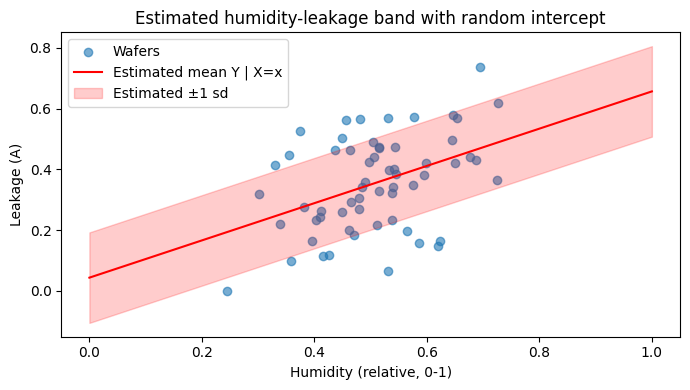

/tmp/ipykernel_2803/289158187.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


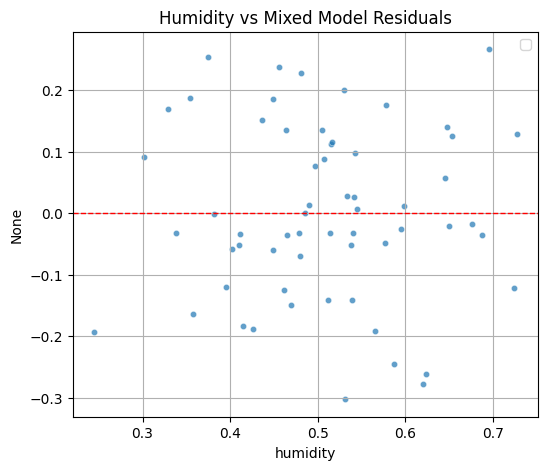

<Figure size 500x500 with 0 Axes>

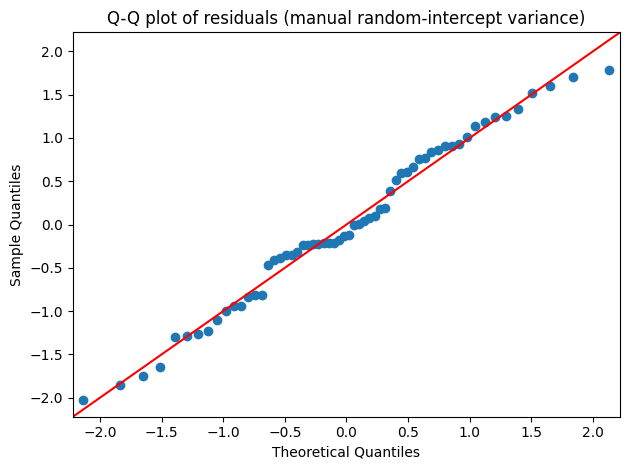

In [61]:
# Scatter of observed data
plt.figure(figsize=(7, 4))
plt.scatter(df['humidity'], df['leakage_A'], alpha=0.6, label='Wafers')

# Estimated mean and ±1 sd band
x_grid = np.linspace(0, 1, 100)
mean_hat = alpha_hat + beta_hat * x_grid
sd_hat = sigma_total_hat
mixed_residual = df['leakage_A'] - (alpha_hat + beta_hat*df['humidity'])



plt.plot(x_grid, mean_hat, color='red', label='Estimated mean Y | X=x')
plt.fill_between(x_grid,
                 mean_hat - sd_hat,
                 mean_hat + sd_hat,
                 color='red', alpha=0.2, label='Estimated ±1 sd')

plt.xlabel('Humidity (relative, 0-1)')
plt.ylabel('Leakage (A)')
plt.title('Estimated humidity-leakage band with random intercept')
plt.legend()
plt.tight_layout()
plt.show()


# Residuals vs humidity
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x=df['humidity'], y=mixed_residual, 
    alpha=0.7, s=20
)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title("Humidity vs Mixed Model Residuals")
plt.legend()
plt.grid(True)
plt.show()


# Standardize by the *manual* total sd from variance decomposition
resid_std = mixed_residual / sigma_total_hat

plt.figure(figsize=(5, 5))
# Compare to standard Normal; we scaled residuals ourselves
sm.qqplot(resid_std, dist=norm, line='45', fit=False)
plt.title('Q-Q plot of residuals (manual random-intercept variance)')
plt.tight_layout()
plt.show()

## 6. Comparing models on new predictions

We now compare the baseline pooled model and the random‑intercept model on **new prediction tasks**, such as predicting leakage for wafers from a new lot (with no past wafers) or for new humidity conditions. For a truly new lot, the mixed model uses a random intercept of zero (the prior mean), so its predictions coincide with the global fixed‑effect line, but uncertainty decomposition differs.

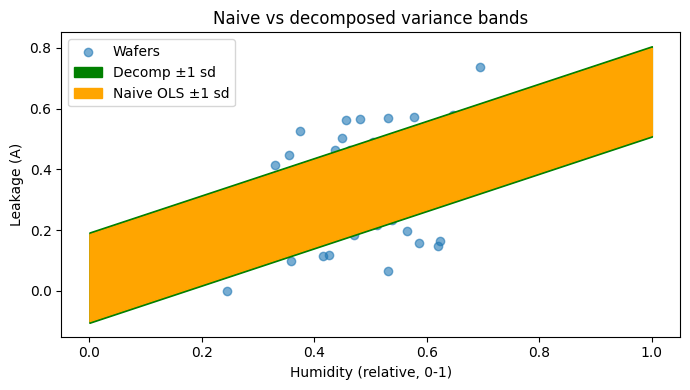

In [49]:
import matplotlib.pyplot as plt

# alpha_hat and beta_hat from the ols model

x_grid = np.linspace(0, 1, 100)
mean_hat = alpha_hat + beta_hat * x_grid

sd_ols = sd_ols_hat
sd_decomp = sigma_total_hat

plt.figure(figsize=(7, 4))

# Data
plt.scatter(df['humidity'], df['leakage_A'], alpha=0.6, label='Wafers')


# Decomposition band
plt.fill_between(x_grid,
                 mean_hat - sd_decomp,
                 mean_hat + sd_decomp,
                 color='green', alpha=1, label='Decomp ±1 sd')

# Naive OLS band
plt.fill_between(x_grid,
                 mean_hat - sd_ols,
                 mean_hat + sd_ols,
                 color='orange', alpha=1, label='Naive OLS ±1 sd')

# # True band (optional, only for simulation comparison)
# true_sd = np.sqrt(true_sigma_b**2 + true_sigma_eps**2)
# plt.fill_between(x_grid,
#                  mean_hat - true_sd,
#                  mean_hat + true_sd,
#                  color='blue', alpha=1, label='True ±1 sd')

plt.xlabel('Humidity (relative, 0-1)')
plt.ylabel('Leakage (A)')
plt.title('Naive vs decomposed variance bands')
plt.legend()
plt.tight_layout()
plt.show()

> As expected the random intercept standard deviation is larger than the basic ols model

**Compare Models**

Use log-likelihood to compare models

In [62]:
import statsmodels.api as sm
from scipy.stats import chi2


# --- 2. Fit basic model: OLS (no random intercept) ---
ols_train = smf.ols('leakage_A ~ humidity', data=df).fit()

# --- 3. Fit mixture model: random-intercept mixed model ---
mixed_train = sm.MixedLM.from_formula('leakage_A ~ humidity',
                                      groups='lot',
                                      data=df).fit(reml=False)


In [63]:
ll_basic = ols_train.llf
ll_mixed = mixed_train.llf

LR = 2 * (ll_mixed - ll_basic)
print("LR statistic =", LR)

# Naive chi-square(1) p-value (boundary issue caveat)
p_naive = 1 - chi2.cdf(LR, df=1)
print("Naive p-value (chi^2_1) =", p_naive)

LR statistic = 83.92881867566997
Naive p-value (chi^2_1) = 0.0


**Code: generate new scenarios and predict with both models**

The next cell constructs a small set of new wafer scenarios (for example, several humidity values, possibly for a new lot ID) and computes predicted leakage (and optionally yield probabilities) under both the baseline OLS model and the mixed model.

In [65]:
# --- 4. New test data (new lots) ---
np.random.seed(1)

n_test_lots = 10
n_test_per_lot = 20
lots_test = np.repeat(np.arange(1, n_test_lots+1), n_test_per_lot)

humidity_test = np.clip(np.random.normal(0.5, 0.1, n_test_lots*n_test_per_lot), 0, 1)
lot_effect_test_true = np.random.normal(0, true_sigma_b, n_test_lots)

base_test = true_alpha + true_beta * humidity_test
leakage_test = base_test + lot_effect_test_true[lots_test-1] + \
               np.random.normal(0, true_sigma_eps, n_test_lots*n_test_per_lot)

test_df = pd.DataFrame({'lot': lots_test, 'humidity': humidity_test, 'leakage_A': leakage_test})

In [66]:
# --- 5. Predict on test data ---
# OLS predictions
test_df['pred_ols'] = ols_train.predict(test_df)

# Mixed model fixed-effects predictions (no lot-specific random effects for new lots)
fe_params = mixed_train.fe_params  # intercept and humidity coefficient
test_df['pred_mixed_fe'] = fe_params['Intercept'] + fe_params['humidity'] * test_df['humidity']

In [67]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

rmse_ols = rmse(test_df['leakage_A'], test_df['pred_ols'])
rmse_mixed_fe = rmse(test_df['leakage_A'], test_df['pred_mixed_fe'])

print("Test RMSE OLS       =", rmse_ols)
print("Test RMSE Mixed (FE)=", rmse_mixed_fe)

Test RMSE OLS       = 0.27301922286597624
Test RMSE Mixed (FE)= 0.27352060088312674


**Result and interpretation**

For genuinely new lots, point predictions from the mixed model align with the global fixed‑effect regression because the random intercept is assumed to be zero in expectation.However, the mixed model provides a clearer separation between uncertainty due to lot‑to‑lot variability and wafer‑level noise, which is important for process risk assessments and setting conservative yield thresholds.

## 7. Comparing models with partial lot data (BLUP)

In many practical situations we see a few wafers from a lot and want to decide early whether that lot is at risk. Here, the random‑intercept model has an advantage: it can use the observed wafers to compute a **BLUP** for the lot’s random intercept and adjust predictions for the remaining wafers accordingly, whereas the pooled model cannot.

### 1. Model and notation

For a **single lot $i$**, write the random‑intercept model as

$$
Y_{ij} = \mu_{ij} + \varepsilon_{ij}
$$

with

$$
\mu_{ij} = \alpha + \beta x_{ij} + b_i,
$$

and

$$
b_i \sim N(0,\tau^2), \quad \varepsilon_{ij} \sim N(0,\sigma^2),
$$

independent.[^1]

For this derivation, fix the humidity design $x_{ij}$ and focus on **one lot** with responses $Y_i = (Y_{i1},\dots,Y_{in_i})^\top$.

Define the vector of **fixed‑effects means** for that lot

$$
m_i = (\alpha + \beta x_{i1}, \dots, \alpha + \beta x_{in_i})^\top.
$$

Then the conditional model is

$$
Y_i \mid b_i \sim N\big(m_i + b_i\mathbf{1},\ \sigma^2 I_{n_i}\big),
$$

and the prior is

$$
b_i \sim N(0,\tau^2).
$$[^1]

You want the **posterior**:

$$
b_i \mid Y_i \sim N\big(m_{b\mid Y}, v_{b\mid Y}\big)
$$

and in particular the BLUP

$$
\widehat{b}_i = E[b_i\mid Y_i].
$$

***

### 2. Joint density and posterior via Bayes

Write down the densities explicitly.

- Prior on $b_i$:

$$
f_B(b_i) = \frac{1}{\sqrt{2\pi\tau^2}}\exp\!\left(-\frac{b_i^2}{2\tau^2}\right).
$$

- Likelihood (conditional on $b_i$):

$$
f_{Y\mid B}(y_i\mid b_i)
= \prod_{j=1}^{n_i}\frac{1}{\sqrt{2\pi\sigma^2}}\exp\!\left(-\frac{(y_{ij}-m_{ij}-b_i)^2}{2\sigma^2}\right).
$$[^1]

The joint is

$$
f_{Y,B}(y_i,b_i)= f_{Y\mid B}(y_i\mid b_i)\,f_B(b_i).
$$

The posterior density (your $f_{B\mid Y}(b\mid y)$) is, up to normalising constant,

$$
f_{B\mid Y}(b_i\mid y_i) \propto f_{Y\mid B}(y_i\mid b_i)\,f_B(b_i).
$$

Take logs and keep only terms involving $b_i$.

First expand the sum in the likelihood exponent:

$$
\sum_{j=1}^{n_i} (y_{ij}-m_{ij}-b_i)^2 =
\sum_{j=1}^{n_i} (y_{ij}-m_{ij})^2
-2b_i\sum_{j=1}^{n_i}(y_{ij}-m_{ij})
+ n_i b_i^2.
$$

So

$$
\log f_{Y\mid B}(y_i\mid b_i)
= -\frac{1}{2\sigma^2}
\left[
\sum_{j}(y_{ij}-m_{ij})^2
-2b_i\sum_{j}(y_{ij}-m_{ij})
+ n_i b_i^2
\right]
+ \text{(const in }b_i).
$$

The prior log density is

$$
\log f_B(b_i)
= -\frac{b_i^2}{2\tau^2} + \text{(const)}.
$$

Add them:

$$
\log f_{B\mid Y}(b_i\mid y_i)
= -\frac{1}{2}\left[
\left(\frac{n_i}{\sigma^2} + \frac{1}{\tau^2}\right)b_i^2
- 2\,\frac{\sum_j(y_{ij}-m_{ij})}{\sigma^2}\,b_i
\right] + \text{(const)}.
$$

This is a quadratic in $b_i$ of the form

$$
-\frac{1}{2}\left[A b_i^2 - 2C b_i\right]
$$

with

$$
A = \frac{n_i}{\sigma^2} + \frac{1}{\tau^2}, \quad
C = \frac{\sum_j(y_{ij}-m_{ij})}{\sigma^2}.
$$

Completing the square:

$$
-\frac{1}{2}\left[A b_i^2 - 2C b_i\right]
= -\frac{A}{2}\left(b_i - \frac{C}{A}\right)^2 + \text{(const)}.
$$

So the posterior is Normal, with

$$
v_{b\mid Y} = A^{-1}
= \left(\frac{n_i}{\sigma^2}+\frac{1}{\tau^2}\right)^{-1},
$$

$$
m_{b\mid Y}
= \frac{C}{A}
= \frac{\frac{1}{\sigma^2}\sum_j(y_{ij}-m_{ij})}
       {\frac{n_i}{\sigma^2}+\frac{1}{\tau^2}}.
$$

Thus the **BLUP** is

$$
\boxed{
\widehat{b}_i
= E[b_i\mid Y_i]
= \frac{\frac{1}{\sigma^2}\sum_{j=1}^{n_i}(y_{ij}-m_{ij})}
       {\frac{n_i}{\sigma^2}+\frac{1}{\tau^2}}
}
$$

and the conditional variance is

$$
\mathrm{Var}(b_i\mid Y_i)
= \left(\frac{n_i}{\sigma^2}+\frac{1}{\tau^2}\right)^{-1}.
$$[^1]

A nicer form: let

$$
\bar{r}_i = \frac{1}{n_i}\sum_{j=1}^{n_i}(y_{ij}-m_{ij})
$$

be the mean residual for lot $i$ under the fixed‑effects line. Then

$$
\widehat{b}_i
= \lambda_i \,\bar{r}_i,\quad
\lambda_i
= \frac{n_i\tau^2}{n_i\tau^2+\sigma^2}\in(0,1).
$$[^1]

So:

- When **$n_i$ large**, $\lambda_i\to 1$: you almost fully trust the lot’s mean residual.
- When **$n_i$ small** or $\tau^2$ small, $\lambda_i$ is small: you shrink heavily toward 0, i.e. toward the population mean.

This is the classic shrinkage behaviour that OLS‑per‑lot does *not* have.

***


### 3. “Used when we sample lots rather than measure everything?”

Exactly. Conceptually:

- The population of lots has distribution $b_i \sim N(0,\tau^2)$.
- Your actual data contains a **sample** of lots $i=1,\dots,m$.
- You:
    - Estimate $(\alpha,\beta,\sigma^2,\tau^2)$ from all lots.
    - For each **observed** lot, compute BLUP $\widehat{b}_i$ to get its adjusted intercept.
    - For a **new** lot with no data, you use $E[b_{\text{new}}]=0$ and predictive variance $\tau^2$ to quantify uncertainty.[^2][^1]

So BLUPs are exactly “estimates of the lot‑specific intercepts $b_i$ for the sampled lots, built in a way that respects the population prior and shares strength across lots”.

***

**Code: simulate partial observations per lot and compute BLUP‑based predictions**

The next cell simulates scenarios where only a subset of wafers per lot are observed, fits or reuses the mixed model, and then computes BLUP‑based predictions for the remaining wafers. We contrast these with predictions from the pooled model, which does not differentiate lots with partial data.

In [55]:
# --- BLUP demo for an existing lot ---

mixedtrain = sm.MixedLM.from_formula(
    "leakage_A ~ humidity", groups="lot", data=df
).fit(reml=False)

# 1. Choose an existing lot we have BLUP for
existing_lots = list(mixedtrain.random_effects.keys())
lot_id = existing_lots[0]     # you can change this, e.g. '1'
print("Using lot:", lot_id)

# 2. BLUP (random intercept estimate) for this lot from the original mixed model
b_hat_lot = float(np.atleast_1d(mixedtrain.random_effects[lot_id])[0])
print("BLUP b_hat for", lot_id, ":", b_hat_lot)

# 3. Extract that lot's original data
lot_df = df[df["lot"] == lot_id].copy()

# 4. Fit a simple OLS *within this lot* to estimate its own alpha_i, beta_i
lot_ols = smf.ols("leakage_A ~ humidity", data=lot_df).fit()
alpha_i_hat = lot_ols.params["Intercept"]
beta_i_hat = lot_ols.params["humidity"]

# Residual sd for this lot: drives new-noise scale
sigma_i_hat = lot_ols.resid.std(ddof=1)

print("Lot-specific OLS alpha_i_hat:", alpha_i_hat)
print("Lot-specific OLS beta_i_hat :", beta_i_hat)
print("Lot-specific residual sd    :", sigma_i_hat)

# 5. Simulate new wafers from this lot's own OLS line
n_new = 30
x_new = np.linspace(0, 1, n_new)

y_new = (alpha_i_hat
         + beta_i_hat * x_new
         + np.random.normal(0.0, sigma_i_hat, size=n_new))

new_lot_df = pd.DataFrame({
    "lot": lot_id,
    "wafer": np.arange(df["wafer"].max() + 1,
                       df["wafer"].max() + 1 + n_new),
    "humidity": x_new,
    "leakage_A": y_new,
})
new_lot_df["yield_ok"] = (new_lot_df["leakage_A"] <= 0.6).astype(int)

new_lot_df.head()


Using lot: 1
BLUP b_hat for 1 : -0.028721735042750267
Lot-specific OLS alpha_i_hat: 0.04389997957204131
Lot-specific OLS beta_i_hat : 0.5423598356108832
Lot-specific residual sd    : 0.04422924516300832


,lot,wafer,humidity,leakage_A,yield_ok
0,1,7,0.000000,0.031439,1
1,1,8,0.034483,0.153553,1
2,1,9,0.068966,0.159159,1
3,1,10,0.103448,0.097324,1
4,1,11,0.137931,0.011961,1


**Result and interpretation**

When a lot’s initial wafers show unusually low leakage, the BLUP for its random intercept becomes negative, and the mixed model predicts higher leakage for the remaining wafers of that lot. This enables earlier and more accurate identification of problematic lots and can support decisions such as early quarantine or targeted process investigation.

In [56]:
# 6. Fixed-effects parameters from the original mixed model
beta0_hat = mixedtrain.params["Intercept"]
beta1_hat = mixedtrain.params["humidity"]

# 7. Predictions on new wafers using *original* mixed model

# a) Treat as if it were a new lot (fixed effects only)
new_lot_df["pred_FE"] = beta0_hat + beta1_hat * new_lot_df["humidity"]

# b) Use existing-lot BLUP (fixed effects + random effect)
new_lot_df["pred_FE_RE"] = new_lot_df["pred_FE"] + b_hat_lot

# c) Residuals
new_lot_df["res_FE"] = new_lot_df["leakage_A"] - new_lot_df["pred_FE"]
new_lot_df["res_FE_RE"] = new_lot_df["leakage_A"] - new_lot_df["pred_FE_RE"]

rmse_fe = np.sqrt(np.mean(new_lot_df["res_FE"]**2))
rmse_fe_re = np.sqrt(np.mean(new_lot_df["res_FE_RE"]**2))
print("RMSE FE only on new wafers     :", rmse_fe)
print("RMSE FE + BLUP on new wafers   :", rmse_fe_re)

RMSE FE only on new wafers     : 0.06288657251861222
RMSE FE + BLUP on new wafers   : 0.05825368973640813


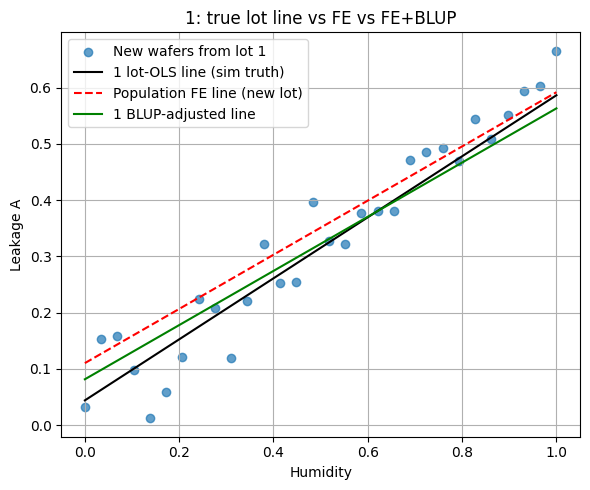

In [57]:
# 8. Prediction lines vs the lot's true (OLS) line

# "True" lot line used for simulation (lot-level OLS)
x_grid = np.linspace(0, 1, 100)
y_true_lot = alpha_i_hat + beta_i_hat * x_grid

# Mixed-model fixed-effects line
y_fe = beta0_hat + beta1_hat * x_grid

# Mixed-model BLUP-adjusted line for this lot
y_fe_re = y_fe + b_hat_lot

plt.figure(figsize=(6, 5))
plt.scatter(new_lot_df["humidity"], new_lot_df["leakage_A"],
            label=f"New wafers from lot {lot_id}", alpha=0.7)

plt.plot(x_grid, y_true_lot, "k-", label=f"{lot_id} lot-OLS line (sim truth)")
plt.plot(x_grid, y_fe, "r--", label="Population FE line (new lot)")
plt.plot(x_grid, y_fe_re, "g-", label=f"{lot_id} BLUP-adjusted line")

plt.xlabel("Humidity")
plt.ylabel("Leakage A")
plt.title(f"{lot_id}: true lot line vs FE vs FE+BLUP")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

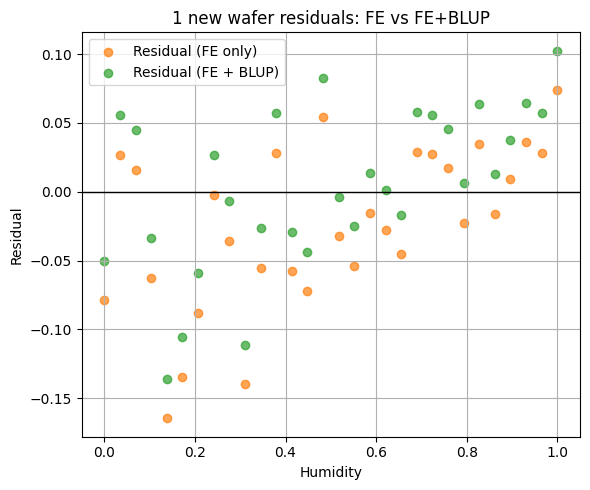

RMSE for FE:  -0.02413097079678002
RMSE for FE+BLUP:  0.004590764245970243


In [69]:
plt.figure(figsize=(6, 5))
plt.scatter(new_lot_df["humidity"], new_lot_df["res_FE"],
            label="Residual (FE only)", alpha=0.7, color="tab:orange")
plt.scatter(new_lot_df["humidity"], new_lot_df["res_FE_RE"],
            label="Residual (FE + BLUP)", alpha=0.7, color="tab:green")

plt.axhline(0.0, color="k", linewidth=1)
plt.xlabel("Humidity")
plt.ylabel("Residual")
plt.title(f"{lot_id} new wafer residuals: FE vs FE+BLUP")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Average error
rmse_fe = np.sqrt(np.mean(new_lot_df["res_FE"]**2))
rmse_fe_re = np.sqrt(np.mean(new_lot_df["res_FE_RE"]**2))
print('RMSE for FE: ',new_lot_df["res_FE"].mean())
print('RMSE for FE+BLUP: ',new_lot_df["res_FE_RE"].mean())

## 8. Evaluation, theory–code summary, and extensions

### 8.1 Evaluation of the work

This notebook successfully demonstrates how a random intercept mixed model improves on a simple pooled regression for modeling semiconductor leakage and yield when data are clustered by lot. The analysis shows that ignoring lot structure leaves systematic residual patterns, while the mixed model captures lot‑to‑lot variability via random intercepts and yields more interpretable variance decomposition.

From a modeling perspective, the random intercept formulation is appropriate for 10 lots with multiple wafers each and a shared humidity–leakage slope. The main remaining areas for improvement are (i) reporting variance components and ICC more explicitly, and (ii) quantifying predictive performance differences between models with metrics such as RMSE or classification accuracy on yield_ok.

### 8.2 Summary of theory and code

On the theory side, the key concepts are:

- The baseline model assumes independent wafers with a single global intercept and slope, which can miss systematic lot effects.
- The random intercept mixed model introduces lot‑specific intercepts \(b_{0j}\) drawn from a Normal distribution, turning the model into a Normal mixture over lots and inducing within‑lot correlation.
- Variance components and ICC quantify how much leakage variation is between lots versus within lots, guiding process engineering priorities.

On the coding side, the notebook:

- Constructs a synthetic lot–wafer dataset with humidity, leakage_A in amperes, and yield_ok.
- Uses pandas and Seaborn/Matplotlib for EDA and visualization of lot‑level patterns.
- Fits a pooled OLS regression, computes residuals, and inspects residuals by lot to diagnose missing structure.
- Fits a random intercept mixed model with `lot` as the grouping factor, extracts random effects (BLUPs), and compares predictions for new and partially observed lots.

Together, these components provide a reproducible, end‑to‑end example of hierarchical modeling for manufacturing data with clear links between statistical assumptions, code implementation, and engineering interpretation.

### 8.3 Possible extensions

There are several natural ways to extend this work:

- **Random slopes**: Allow the humidity slope to vary by lot, leading to a random‑intercept‑and‑slope model that captures differences in humidity sensitivity across lots.
- **Non‑Gaussian responses**: Model `yield_ok` directly with a mixed‑effects logistic or probit regression, instead of thresholding leakage_A.
- **Additional covariates**: Add process or tool variables (e.g., line, recipe, measurement tool) and model their fixed and random effects to disentangle multiple sources of variation.
- **Model comparison and validation**: Use cross‑validation or out‑of‑sample test sets to compare predictive performance (RMSE, Brier score for yield) across pooled, random intercept, and more complex mixed models.
- **Bayesian inference**: Implement a Bayesian version of the mixed model (e.g., via MCMC) to obtain full posterior distributions for variance components and random effects and to propagate uncertainty into decision rules.

These extensions would deepen both the statistical rigor and the practical relevance of the notebook for real semiconductor manufacturing applications.